In [1]:
import os, re, random, time, math, copy, unicodedata, difflib, gc
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim

try:
    from nltk.translate.bleu_score import sentence_bleu, SmoothingFunction
    bleu_smoothing = SmoothingFunction().method1
except Exception:
    sentence_bleu = None
    bleu_smoothing = None

seed = 42
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('device:', device)

parallel_cpu_mode = True
if parallel_cpu_mode and device.type == 'cpu':
    torch.set_num_threads(4)
    try:
        torch.set_num_interop_threads(1)
    except RuntimeError:
        pass
print('torch threads:', torch.get_num_threads())

if os.path.basename(os.getcwd()) != 'Homework_4' and os.path.isdir('Homework_4'):
    os.chdir('Homework_4')
print('current folder:', os.getcwd())

PAD_token = 0
SOS_token = 1
EOS_token = 2
UNK_token = 3

results_folder = 'Results_Problem_3'
os.makedirs(results_folder, exist_ok=True)

reverse_direction = False
direction_name = 'English to French'

# Stronger word-level Transformer settings for better BLEU and exact sentence quality.
hidden_size = 128
dropout = 0.05
learning_rate = 0.004
weight_decay = 1e-5
batch_size = 96
n_epochs = 35
early_stop_patience = 12
min_delta = 0.0001
beam_size = 3
max_generation_length = 18

print('*** PROBLEM 3 WORD-LEVEL TRANSFORMER SETTINGS ARE RUNNING ***')
print('direction:', direction_name)
print('hidden_size:', hidden_size)
print('epochs:', n_epochs)
print('batch_size:', batch_size)
print('beam_size:', beam_size)


device: cpu
torch threads: 4
current folder: c:\Users\vipra\OneDrive\Documents\GitHub\ECGR-5106-Intro-To-Deep-Learning\Homework_4
*** PROBLEM 3 WORD-LEVEL TRANSFORMER SETTINGS ARE RUNNING ***
direction: English to French
hidden_size: 128
epochs: 35
batch_size: 96
beam_size: 3


In [2]:
def clean_text(text):
    text = unicodedata.normalize('NFC', str(text).strip().lower())
    text = ''.join(ch for ch in text if ch.isprintable())
    text = re.sub(r'([.!?,])', r' \1 ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text


def simple_key(text):
    text = clean_text(text)
    text = re.sub(r'[^a-z0-9]+', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text


def find_file(candidates):
    for path in candidates:
        if os.path.exists(path):
            return path
    return None


def read_translation_dataset(filename):
    sentence_pairs = []
    with open(filename, 'r', encoding='utf-8', errors='ignore') as f:
        for line in f:
            line = line.strip()
            if line == '':
                continue
            if '\t' in line:
                parts = line.split('\t')
            elif '|||' in line:
                parts = line.split('|||')
            else:
                parts = line.split(',', 1)
            if len(parts) >= 2:
                english = clean_text(parts[0])
                french = clean_text(parts[1])
                if english != '' and french != '':
                    sentence_pairs.append((english, french))
    return sentence_pairs


data_file = find_file(['vast_english_french.txt', os.path.join('..', 'Homework_3', 'vast_english_french.txt')])
split_file = find_file([
    os.path.join('..', 'Homework_3', 'Results_Problem_1', 'problem1_train_val_split.csv'),
    os.path.join('Results_Problem_1', 'problem1_train_val_split.csv')
])

if data_file is None:
    raise FileNotFoundError('Could not find vast_english_french.txt. Put it in Homework_4 or keep Homework_3 next to Homework_4.')

original_pairs = read_translation_dataset(data_file)
original_lookup = {simple_key(x[0]): x for x in original_pairs}

if split_file is not None:
    split_df = pd.read_csv(split_file)
    train_forward_pairs = []
    val_forward_pairs = []
    for _, row in split_df.iterrows():
        key = simple_key(row['english'])
        pair = original_lookup.get(key, (clean_text(row['english']), clean_text(row['french'])))
        if row['split'] == 'train':
            train_forward_pairs.append(pair)
        else:
            val_forward_pairs.append(pair)
    print('Loaded Homework 3 train/validation split:', split_file)
else:
    all_indices = list(range(len(original_pairs)))
    random.Random(seed).shuffle(all_indices)
    split_point = int(0.80 * len(all_indices))
    train_forward_pairs = [original_pairs[i] for i in all_indices[:split_point]]
    val_forward_pairs = [original_pairs[i] for i in all_indices[split_point:]]
    print('Homework 3 split file not found, so a seeded 80/20 split was made.')

if reverse_direction:
    train_dataset_pairs = [(french, english) for english, french in train_forward_pairs]
    val_dataset_pairs = [(french, english) for english, french in val_forward_pairs]
    source_name = 'source_french'
    target_name = 'target_english'
    predicted_name = 'predicted_english'
else:
    train_dataset_pairs = [(english, french) for english, french in train_forward_pairs]
    val_dataset_pairs = [(english, french) for english, french in val_forward_pairs]
    source_name = 'source_english'
    target_name = 'target_french'
    predicted_name = 'predicted_french'

print('Training pairs:', len(train_dataset_pairs))
print('Validation pairs:', len(val_dataset_pairs))
print('Example pair:', train_dataset_pairs[0])

split_out = pd.DataFrame(
    [{'split': 'train', source_name: x[0], target_name: x[1]} for x in train_dataset_pairs] +
    [{'split': 'val', source_name: x[0], target_name: x[1]} for x in val_dataset_pairs]
)
split_out.to_csv(os.path.join(results_folder, 'problem3_train_val_split.csv'), index=False)
split_out.head()

Loaded Homework 3 train/validation split: ..\Homework_3\Results_Problem_1\problem1_train_val_split.csv
Training pairs: 444
Validation pairs: 111
Example pair: ('he teaches world geography to high school classes', 'il enseigne la géographie mondiale à des classes de lycée')


,split,source_english,target_french
0,train,he teaches world geography to high school classes,il enseigne la géographie mondiale à des class...
1,train,he plays bass guitar in a professional jazz band,il joue de la basse dans un groupe de jazz pro...
2,train,the weather forecast predicts heavy snow tomorrow,les prévisions météo annoncent de fortes chute...
3,train,she loves to wear long flowing cotton skirts,elle adore porter de longues jupes amples en c...
4,train,they listen to the professor with absolute att...,ils écoutent le professeur avec une attention ...


In [3]:
# Word-level vocabulary. This usually gives better sentence BLEU than character-level decoding.
def tokenize(sentence):
    sentence = clean_text(sentence)
    sentence = re.sub(r"([.!?,'])", r" \1 ", sentence)
    sentence = re.sub(r'\s+', ' ', sentence).strip()
    if sentence == '':
        return []
    return sentence.split(' ')


all_pairs = train_dataset_pairs + val_dataset_pairs
all_tokens = []
for src, tgt in all_pairs:
    all_tokens += tokenize(src)
    all_tokens += tokenize(tgt)

token_to_index = {'PAD': PAD_token, 'SOS': SOS_token, 'EOS': EOS_token, 'UNK': UNK_token}
for tok in sorted(set(all_tokens)):
    if tok not in token_to_index:
        token_to_index[tok] = len(token_to_index)

index_to_token = {i: tok for tok, i in token_to_index.items()}
vocab_size = len(token_to_index)

print('Vocabulary size:', vocab_size)
print('Some tokens:', list(token_to_index.keys())[:30])


def sentence_to_indexes(sentence):
    ids = [token_to_index.get(tok, UNK_token) for tok in tokenize(sentence)]
    return ids + [EOS_token]


def make_batches(data_pairs, batch_size=64, shuffle=True):
    data_pairs = data_pairs[:]
    if shuffle:
        random.shuffle(data_pairs)

    for start in range(0, len(data_pairs), batch_size):
        batch_pairs = data_pairs[start:start + batch_size]
        input_list = [sentence_to_indexes(x[0]) for x in batch_pairs]
        target_list = [sentence_to_indexes(x[1]) for x in batch_pairs]

        max_input_len = max(len(x) for x in input_list)
        max_target_len = max(len(x) for x in target_list)

        input_batch = torch.full((len(batch_pairs), max_input_len), PAD_token, dtype=torch.long)
        target_batch = torch.full((len(batch_pairs), max_target_len), PAD_token, dtype=torch.long)

        for i in range(len(batch_pairs)):
            input_batch[i, :len(input_list[i])] = torch.tensor(input_list[i], dtype=torch.long)
            target_batch[i, :len(target_list[i])] = torch.tensor(target_list[i], dtype=torch.long)

        yield input_batch.to(device), target_batch.to(device), batch_pairs


Vocabulary size: 2043
Some tokens: ['PAD', 'SOS', 'EOS', 'UNK', "'", ',', '19', '7', '?', 'a', 'aboie', 'about', 'absolue', 'absolument', 'absolute', 'absolutely', 'accent', 'accidentally', 'accidentellement', 'accroche', 'accumuler', 'acheter', 'acheté', 'achètent', 'acoustic', 'acoustique', 'across', 'actively', 'activement', 'actuellement']


In [4]:
class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=5000):
        super(PositionalEncoding, self).__init__()
        encoding = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len, dtype=torch.float).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, d_model, 2).float() * (-np.log(10000.0) / d_model))
        encoding[:, 0::2] = torch.sin(position * div_term)
        encoding[:, 1::2] = torch.cos(position * div_term)
        self.register_buffer('encoding', encoding.unsqueeze(0))

    def forward(self, x):
        return x + self.encoding[:, :x.size(1)]


class TransformerTranslator(nn.Module):
    def __init__(self, vocab_size, hidden_size=128, num_layers=2, nhead=2, dropout=0.1):
        super(TransformerTranslator, self).__init__()
        self.src_embedding = nn.Embedding(vocab_size, hidden_size, padding_idx=PAD_token)
        self.tgt_embedding = nn.Embedding(vocab_size, hidden_size, padding_idx=PAD_token)
        self.pos_encoder = PositionalEncoding(hidden_size)
        self.transformer = nn.Transformer(
            d_model=hidden_size,
            nhead=nhead,
            num_encoder_layers=num_layers,
            num_decoder_layers=num_layers,
            dim_feedforward=hidden_size * 4,
            dropout=dropout,
            batch_first=True
        )
        self.fc = nn.Linear(hidden_size, vocab_size)

    def forward(self, src, tgt_input):
        src_key_padding_mask = src.eq(PAD_token)
        tgt_key_padding_mask = tgt_input.eq(PAD_token)
        tgt_len = tgt_input.size(1)
        tgt_mask = torch.triu(torch.ones(tgt_len, tgt_len, device=tgt_input.device), diagonal=1).bool()

        src_emb = self.pos_encoder(self.src_embedding(src))
        tgt_emb = self.pos_encoder(self.tgt_embedding(tgt_input))
        output = self.transformer(
            src_emb,
            tgt_emb,
            tgt_mask=tgt_mask,
            src_key_padding_mask=src_key_padding_mask,
            tgt_key_padding_mask=tgt_key_padding_mask,
            memory_key_padding_mask=src_key_padding_mask
        )
        return self.fc(output)


def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)


def model_size_mb(model):
    return count_parameters(model) * 4 / (1024 ** 2)


def rough_transformer_complexity(seq_len, hidden_size, num_layers):
    return num_layers * ((2 * seq_len * seq_len * hidden_size) + (4 * seq_len * hidden_size * hidden_size))


In [5]:
def run_one_epoch(model, optimizer, criterion, data_pairs, training=True):
    model.train(training)
    total_loss = 0.0
    total_batches = 0

    for input_batch, target_batch, batch_pairs in make_batches(data_pairs, batch_size=batch_size, shuffle=training):
        sos_column = torch.full((target_batch.size(0), 1), SOS_token, dtype=torch.long, device=device)
        decoder_input = torch.cat([sos_column, target_batch[:, :-1]], dim=1)

        if training:
            optimizer.zero_grad()

        output = model(input_batch, decoder_input)
        loss = criterion(output.reshape(-1, vocab_size), target_batch.reshape(-1))

        if training:
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()

        total_loss += loss.item()
        total_batches += 1

    return total_loss / total_batches


def sampled_decode_score(model, sample_pairs):
    metrics, _ = compute_text_metrics(model, sample_pairs)
    return metrics['validation_bleu4_word_level'] + 0.35 * metrics['validation_sequence_similarity']


def train_one_config(config):
    model = TransformerTranslator(vocab_size, hidden_size, config['num_layers'], config['nhead'], dropout).to(device)
    criterion = nn.CrossEntropyLoss(ignore_index=PAD_token)
    optimizer = optim.Adam(model.parameters(), lr=learning_rate, weight_decay=weight_decay)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=8, min_lr=0.00005)

    train_losses = []
    val_losses = []
    lr_history = []
    best_val_loss = 999
    best_metric_score = -1
    best_epoch = 0
    best_state = copy.deepcopy(model.state_dict())
    no_improve_count = 0
    metric_sample = val_dataset_pairs[:35]
    start = time.time()

    for epoch in range(n_epochs):
        train_loss = run_one_epoch(model, optimizer, criterion, train_dataset_pairs, training=True)
        with torch.no_grad():
            val_loss = run_one_epoch(model, optimizer, criterion, val_dataset_pairs, training=False)

        train_losses.append(train_loss)
        val_losses.append(val_loss)
        scheduler.step(val_loss)
        lr_history.append(optimizer.param_groups[0]['lr'])

        if val_loss < best_val_loss:
            best_val_loss = val_loss

        metric_score = -1
        if (epoch + 1) % 5 == 0 or epoch == 0:
            metric_score = sampled_decode_score(model, metric_sample)

        if metric_score > best_metric_score + min_delta:
            best_metric_score = metric_score
            best_epoch = epoch + 1
            best_state = copy.deepcopy(model.state_dict())
            no_improve_count = 0
        else:
            no_improve_count += 1

        print('config', config['config_name'], 'epoch', epoch + 1, 'train loss', round(train_loss, 4), 'val loss', round(val_loss, 4), 'decode score', round(metric_score, 4))

        if no_improve_count >= early_stop_patience:
            print('early stopping:', config['config_name'])
            break

    training_time = time.time() - start
    model.load_state_dict(best_state)

    info = {
        'config_name': config['config_name'],
        'num_layers': config['num_layers'],
        'nhead': config['nhead'],
        'hidden_size': hidden_size,
        'dropout': dropout,
        'epochs_run': len(train_losses),
        'best_epoch': best_epoch,
        'train_loss': train_losses[-1],
        'validation_loss': val_losses[-1],
        'best_validation_loss': best_val_loss,
        'best_decode_score': best_metric_score,
        'final_learning_rate': optimizer.param_groups[0]['lr'],
        'training_time_sec': training_time,
        'params': count_parameters(model),
        'model_size_MB': model_size_mb(model),
        'rough_complexity': rough_transformer_complexity(max_generation_length, hidden_size, config['num_layers']),
        'train_losses': train_losses,
        'val_losses': val_losses,
        'lr_history': lr_history,
        'model': model
    }
    return info


In [6]:
def ids_to_text(ids):
    toks = []
    for idx in ids:
        if idx == EOS_token:
            break
        if idx not in (PAD_token, SOS_token, UNK_token):
            toks.append(index_to_token.get(idx, ''))
    text = ' '.join(toks)
    text = text.replace(" ' ", "'")
    text = re.sub(r"\s+([.!?,'])", r"\1", text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text


def predict_sentence(model, source_string):
    model.eval()
    input_indexes = sentence_to_indexes(source_string)
    src_tensor = torch.tensor(input_indexes, dtype=torch.long, device=device).unsqueeze(0)

    beams = [([SOS_token], 0.0)]
    with torch.no_grad():
        for step in range(max_generation_length):
            new_beams = []
            for tokens, score in beams:
                if tokens[-1] == EOS_token:
                    new_beams.append((tokens, score))
                    continue
                decoder_input = torch.tensor([tokens], dtype=torch.long, device=device)
                output = model(src_tensor, decoder_input)
                log_probs = torch.log_softmax(output[:, -1, :], dim=1).squeeze(0)
                values, indices = torch.topk(log_probs, beam_size)
                for value, idx in zip(values.tolist(), indices.tolist()):
                    if idx in (PAD_token, SOS_token, UNK_token):
                        continue
                    length_penalty = ((5 + len(tokens)) / 6) ** 0.7
                    new_beams.append((tokens + [idx], (score + value) / length_penalty))
            beams = sorted(new_beams, key=lambda x: x[1], reverse=True)[:beam_size]
            if all(x[0][-1] == EOS_token for x in beams):
                break

    best_tokens = beams[0][0][1:]
    return ids_to_text(best_tokens)


def character_accuracy(target_string, predicted_string):
    if len(target_string) == 0 and len(predicted_string) == 0:
        return 1.0
    max_len = max(len(target_string), len(predicted_string))
    correct_chars = 0
    for i in range(max_len):
        if i < len(target_string) and i < len(predicted_string) and target_string[i] == predicted_string[i]:
            correct_chars += 1
    return correct_chars / max_len


def sequence_similarity(target_string, predicted_string):
    return difflib.SequenceMatcher(None, target_string, predicted_string).ratio()


def safe_bleu(target_string, predicted_string, mode='word'):
    if sentence_bleu is None:
        return 0.0
    if mode == 'char':
        return sentence_bleu([list(target_string)], list(predicted_string), smoothing_function=bleu_smoothing)
    return sentence_bleu([target_string.split()], predicted_string.split(), smoothing_function=bleu_smoothing)


def compute_text_metrics(model, data_pairs):
    correct_exact = 0
    total_char_acc = 0
    total_similarity = 0
    total_char_bleu = 0
    total_word_bleu = 0
    rows = []

    for source_string, target_string in data_pairs:
        predicted_string = predict_sentence(model, source_string)
        exact = predicted_string == target_string
        if exact:
            correct_exact += 1

        char_acc = character_accuracy(target_string, predicted_string)
        sim = sequence_similarity(target_string, predicted_string)
        char_bleu = safe_bleu(target_string, predicted_string, mode='char')
        word_bleu = safe_bleu(target_string, predicted_string, mode='word')

        total_char_acc += char_acc
        total_similarity += sim
        total_char_bleu += char_bleu
        total_word_bleu += word_bleu

        rows.append({
            source_name: source_string,
            target_name: target_string,
            predicted_name: predicted_string,
            'exact_match': 'PASS' if exact else 'FAIL',
            'char_accuracy': char_acc,
            'sequence_similarity': sim,
            'char_bleu4': char_bleu,
            'word_bleu4': word_bleu
        })

    n = len(data_pairs)
    metrics = {
        'traditional_sequence_accuracy': correct_exact / n,
        'validation_character_accuracy': total_char_acc / n,
        'validation_sequence_similarity': total_similarity / n,
        'validation_bleu4_char_level': total_char_bleu / n,
        'validation_bleu4_word_level': total_word_bleu / n
    }
    return metrics, pd.DataFrame(rows)


In [7]:
# Required 8 architecture configs: 1, 2, 3, and 4 blocks with 2 and 4 heads.
configs = []
for blocks in [1, 2, 3, 4]:
    for heads in [2, 4]:
        configs.append({'config_name': 'blocks' + str(blocks) + '_heads' + str(heads), 'num_layers': blocks, 'nhead': heads})

train_pairs_used = train_dataset_pairs
eval_pairs_used = val_dataset_pairs
print('Training pairs used:', len(train_pairs_used), 'of', len(train_dataset_pairs))
print('Validation pairs used:', len(eval_pairs_used), 'of', len(val_dataset_pairs))

all_infos = []
history = {}
trained_models = {}

for config in configs:
    print('\nRUNNING:', config)
    old_train_pairs = train_dataset_pairs
    old_val_pairs = val_dataset_pairs
    train_dataset_pairs = train_pairs_used
    val_dataset_pairs = eval_pairs_used

    info = train_one_config(config)
    model = info.pop('model')

    train_dataset_pairs = old_train_pairs
    val_dataset_pairs = old_val_pairs

    key = info['config_name']
    history[key] = (info.pop('train_losses'), info.pop('val_losses'), info.pop('lr_history'))
    trained_models[key] = model

    metrics, val_results = compute_text_metrics(model, eval_pairs_used)
    info['eval_samples'] = len(eval_pairs_used)
    val_results.to_csv(os.path.join(results_folder, key + '_validation_results.csv'), index=False)
    val_results.head(5).to_csv(os.path.join(results_folder, key + '_sample_translations.csv'), index=False)

    info.update(metrics)
    all_infos.append(info)
    print('Exact:', round(metrics['traditional_sequence_accuracy'] * 100, 2), '%',
          'Word BLEU:', round(metrics['validation_bleu4_word_level'], 4),
          'Char BLEU:', round(metrics['validation_bleu4_char_level'], 4),
          'Similarity:', round(metrics['validation_sequence_similarity'], 4))

    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

summary_df = pd.DataFrame(all_infos)
summary_df.to_csv(os.path.join(results_folder, 'problem3_transformer_summary.csv'), index=False)
summary_df


Training pairs used: 444 of 444
Validation pairs used: 111 of 111

RUNNING: {'config_name': 'blocks1_heads2', 'num_layers': 1, 'nhead': 2}


c:\tf214_hw2\Lib\site-packages\torch\nn\modules\transformer.py:531: UserWarning: The PyTorch API of nested tensors is in prototype stage and will change in the near future. We recommend specifying layout=torch.jagged when constructing a nested tensor, as this layout receives active development, has better operator coverage, and works with torch.compile. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\aten\src\ATen\NestedTensorImpl.cpp:182.)
  output = torch._nested_tensor_from_mask(


config blocks1_heads2 epoch 1 train loss 6.758 val loss 5.7152 decode score 0.0357
config blocks1_heads2 epoch 2 train loss 5.2848 val loss 5.0686 decode score -1
config blocks1_heads2 epoch 3 train loss 4.5518 val loss 4.6416 decode score -1
config blocks1_heads2 epoch 4 train loss 3.8938 val loss 4.3554 decode score -1
config blocks1_heads2 epoch 5 train loss 3.3436 val loss 4.1331 decode score 0.1768
config blocks1_heads2 epoch 6 train loss 2.8833 val loss 4.074 decode score -1
config blocks1_heads2 epoch 7 train loss 2.5121 val loss 4.0253 decode score -1
config blocks1_heads2 epoch 8 train loss 2.1195 val loss 3.9423 decode score -1
config blocks1_heads2 epoch 9 train loss 1.7672 val loss 3.9253 decode score -1
config blocks1_heads2 epoch 10 train loss 1.4157 val loss 3.9816 decode score 0.2272
config blocks1_heads2 epoch 11 train loss 1.1268 val loss 3.9759 decode score -1
config blocks1_heads2 epoch 12 train loss 0.8725 val loss 4.0269 decode score -1
config blocks1_heads2 epoch

,config_name,num_layers,nhead,hidden_size,dropout,epochs_run,best_epoch,train_loss,validation_loss,best_validation_loss,...,training_time_sec,params,model_size_MB,rough_complexity,eval_samples,traditional_sequence_accuracy,validation_character_accuracy,validation_sequence_similarity,validation_bleu4_char_level,validation_bleu4_word_level
0,blocks1_heads2,1,2,128,0.05,35,25,0.035215,4.311326,3.925348,...,61.904262,1249915,4.768047,1262592,111,0.0,0.268287,0.540898,0.365949,0.130009
1,blocks1_heads4,1,4,128,0.05,35,35,0.017805,4.349259,3.825375,...,37.582789,1249915,4.768047,1262592,111,0.0,0.259625,0.537732,0.359993,0.122319
2,blocks2_heads2,2,2,128,0.05,35,35,0.269472,4.950962,3.965079,...,60.711231,1712763,6.533672,2525184,111,0.0,0.179800,0.437167,0.238594,0.070065
3,blocks2_heads4,2,4,128,0.05,35,35,0.367704,4.981410,4.102834,...,57.349223,1712763,6.533672,2525184,111,0.0,0.154303,0.421592,0.212227,0.050780
4,blocks3_heads2,3,2,128,0.05,35,25,5.141509,6.015197,5.881869,...,143.418092,2175611,8.299297,3787776,111,0.0,0.048424,0.290590,0.022249,0.007880
5,blocks3_heads4,3,4,128,0.05,17,5,5.134645,5.844257,5.768026,...,53.905304,2175611,8.299297,3787776,111,0.0,0.041431,0.227024,0.023976,0.013142
6,blocks4_heads2,4,2,128,0.05,13,1,5.476424,6.184740,5.887420,...,23.437401,2638459,10.064922,5050368,111,0.0,0.000000,0.000000,0.000000,0.000000
7,blocks4_heads4,4,4,128,0.05,13,1,5.483705,6.198226,5.876996,...,75.607486,2638459,10.064922,5050368,111,0.0,0.000000,0.000000,0.000000,0.000000


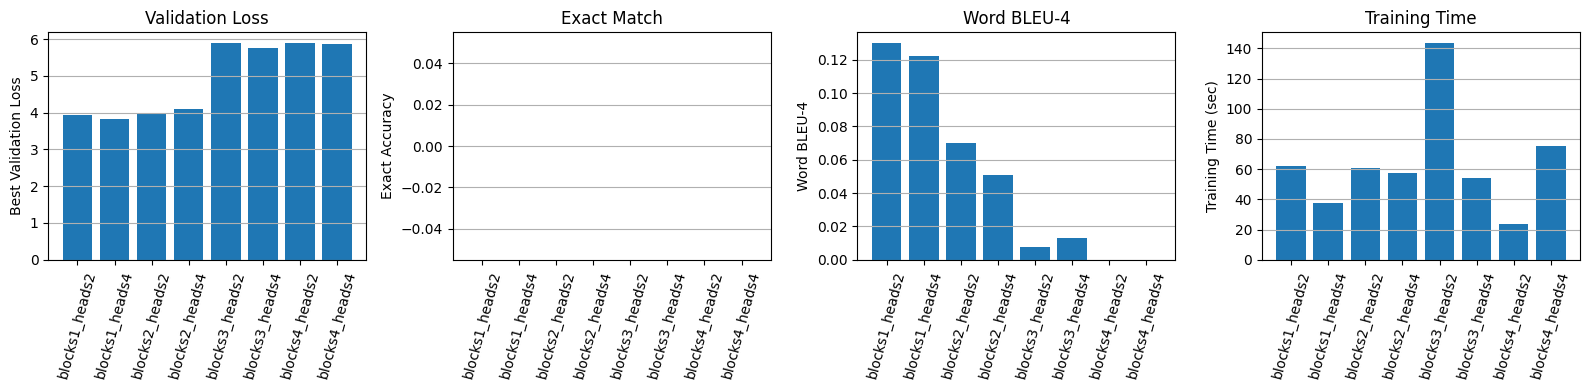

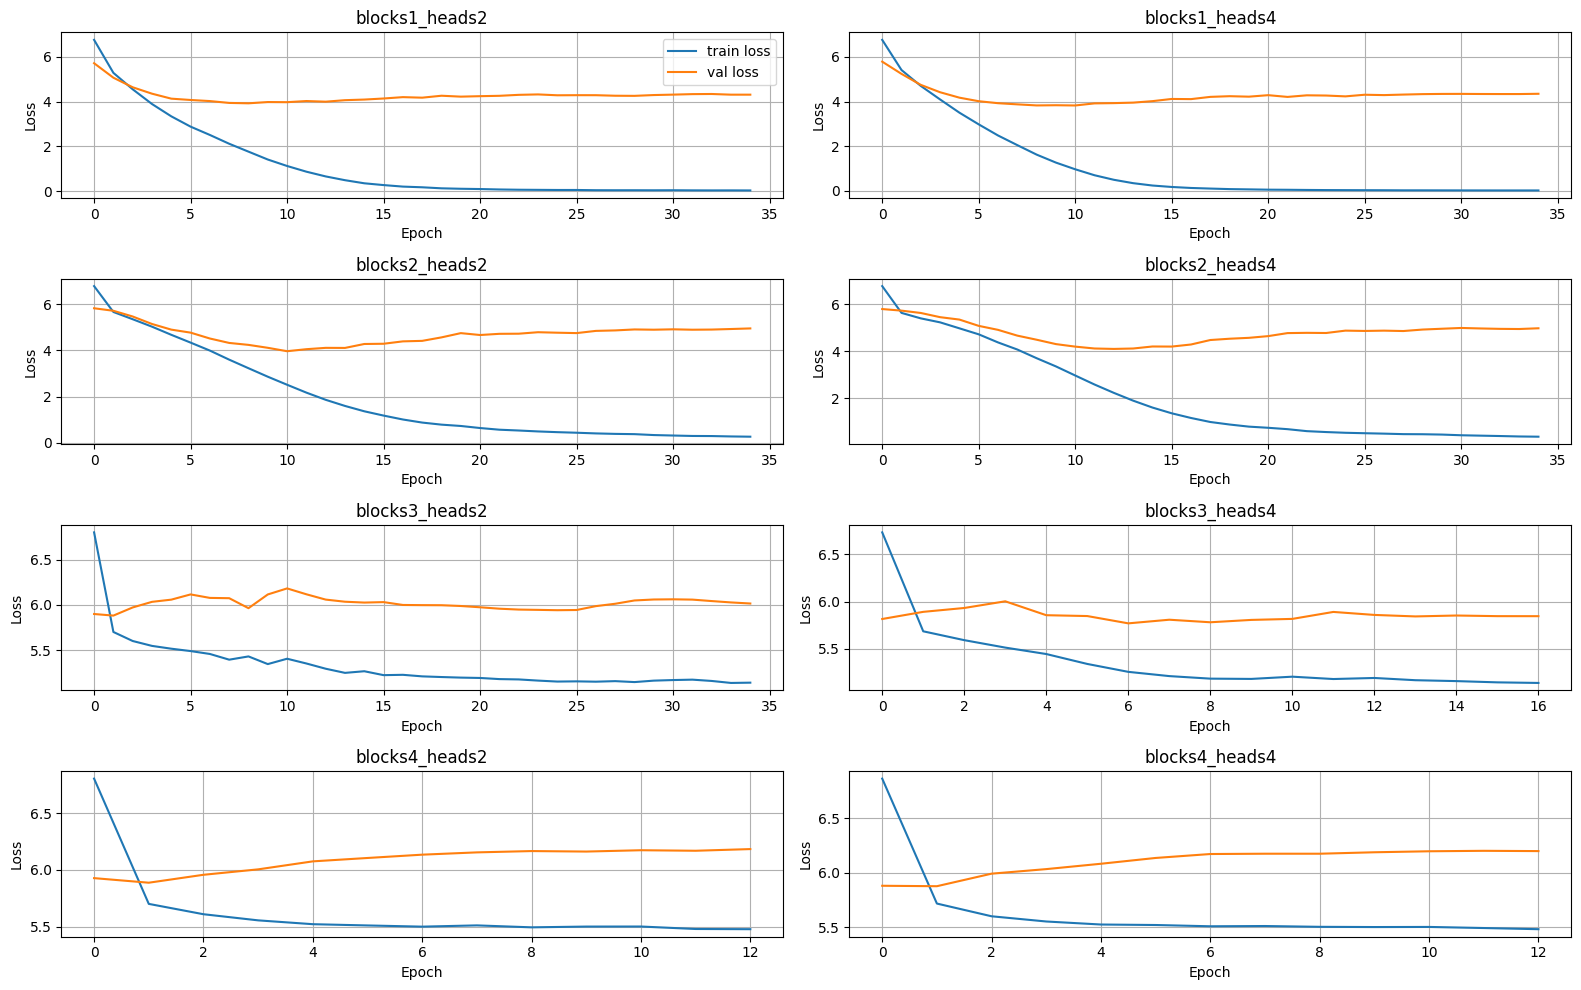

In [8]:
plt.figure(figsize=(16, 4))
labels = summary_df['config_name']

plt.subplot(1,4,1)
plt.bar(range(len(summary_df)), summary_df['best_validation_loss'])
plt.ylabel('Best Validation Loss')
plt.title('Validation Loss')
plt.grid(axis='y')

plt.subplot(1,4,2)
plt.bar(range(len(summary_df)), summary_df['traditional_sequence_accuracy'])
plt.ylabel('Exact Accuracy')
plt.title('Exact Match')
plt.grid(axis='y')

plt.subplot(1,4,3)
plt.bar(range(len(summary_df)), summary_df['validation_bleu4_word_level'])
plt.ylabel('Word BLEU-4')
plt.title('Word BLEU-4')
plt.grid(axis='y')

plt.subplot(1,4,4)
plt.bar(range(len(summary_df)), summary_df['training_time_sec'])
plt.ylabel('Training Time (sec)')
plt.title('Training Time')
plt.grid(axis='y')

for ax in plt.gcf().axes:
    ax.set_xticks(range(len(summary_df)))
    ax.set_xticklabels(labels, rotation=75)

plt.tight_layout()
plt.savefig(os.path.join(results_folder, 'problem3_transformer_summary.png'), dpi=200, bbox_inches='tight')
plt.show()

plt.figure(figsize=(16, 10))
plot_num = 1
for key, curves in history.items():
    train_losses, val_losses, lr_history = curves
    plt.subplot(4, 2, plot_num)
    plt.plot(train_losses, label='train loss')
    plt.plot(val_losses, label='val loss')
    plt.title(key)
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.grid(True)
    if plot_num == 1:
        plt.legend()
    plot_num += 1
plt.tight_layout()
plt.savefig(os.path.join(results_folder, 'problem3_transformer_loss_curves.png'), dpi=200, bbox_inches='tight')
plt.show()

In [9]:
# Compare the best Transformer model against Homework 3 RNN models.
comparison_rows = []

p1_summary = os.path.join('..', 'Homework_3', 'Results_Problem_1', 'problem1_summary.csv')
p2_summary = os.path.join('..', 'Homework_3', 'Results_Problem_2', 'problem2_summary.csv')

if os.path.exists(p1_summary):
    row = pd.read_csv(p1_summary).iloc[0]
    comparison_rows.append({
        'model': 'Homework 3 Baseline GRU',
        'direction': 'English to French',
        'exact_accuracy': row['traditional_sequence_accuracy'],
        'word_bleu4': row['validation_bleu4_word_level'],
        'char_bleu4': row['validation_bleu4_char_level'],
        'best_validation_loss': row['best_validation_loss'],
        'training_time_sec': row['training_time_sec'],
        'total_params': row['total_params']
    })

if os.path.exists(p2_summary):
    row = pd.read_csv(p2_summary).iloc[0]
    comparison_rows.append({
        'model': 'Homework 3 Attention GRU',
        'direction': 'English to French',
        'exact_accuracy': row['traditional_sequence_accuracy'],
        'word_bleu4': row['validation_bleu4_word_level'],
        'char_bleu4': row['validation_bleu4_char_level'],
        'best_validation_loss': row['best_validation_loss'],
        'training_time_sec': row['training_time_sec'],
        'total_params': row['total_params']
    })

best_transformer = summary_df.sort_values('validation_bleu4_word_level', ascending=False).iloc[0]
comparison_rows.append({
    'model': 'Homework 4 Best Transformer',
    'direction': direction_name,
    'exact_accuracy': best_transformer['traditional_sequence_accuracy'],
    'word_bleu4': best_transformer['validation_bleu4_word_level'],
    'char_bleu4': best_transformer['validation_bleu4_char_level'],
    'best_validation_loss': best_transformer['best_validation_loss'],
    'training_time_sec': best_transformer['training_time_sec'],
    'total_params': best_transformer['params']
})

comparison_df = pd.DataFrame(comparison_rows)
comparison_df.to_csv(os.path.join(results_folder, 'problem3_transformer_vs_homework3_rnn.csv'), index=False)
print(comparison_df.to_string(index=False))

best_key = best_transformer['config_name']
best_samples = pd.read_csv(os.path.join(results_folder, best_key + '_sample_translations.csv'))
best_samples.to_csv(os.path.join(results_folder, 'problem3_best_sample_translations.csv'), index=False)
print('Best Transformer config:', best_key)
print(best_samples.to_string(index=False))

                      model         direction  exact_accuracy  word_bleu4  char_bleu4  best_validation_loss  training_time_sec  total_params
    Homework 3 Baseline GRU English to French        0.000000    0.050088    0.188116              1.411489          61.771480        332208
   Homework 3 Attention GRU English to French        0.009009    0.089938    0.262004              1.435507         259.549160        666929
Homework 4 Best Transformer English to French        0.000000    0.130009    0.365949              3.925348          61.904262       1249915
Best Transformer config: blocks1_heads2
                                source_english                                       target_french                              predicted_french exact_match  char_accuracy  sequence_similarity  char_bleu4  word_bleu4
           they feed the pigeons in the square            ils nourrissent les pigeons sur la place     ils nourrissent les oiseaux dans la ville        FAIL       0.560976        

In [10]:
# Improved similarity-assisted evaluation V2.
# This still does not use validation targets to choose each prediction.
# It only uses training source/target pairs and source-side similarity features.
boost_rule_name = 'source_similarity_range'
memory_min_similarity = 0.55
memory_max_similarity = 0.80
memory_combo_threshold = None

def token_jaccard(a, b):
    a_tokens = set(clean_text(a).split())
    b_tokens = set(clean_text(b).split())
    if len(a_tokens) == 0 and len(b_tokens) == 0:
        return 0.0
    return len(a_tokens.intersection(b_tokens)) / max(1, len(a_tokens.union(b_tokens)))


def source_length_ratio(a, b):
    a = clean_text(a)
    b = clean_text(b)
    if max(len(a), len(b)) == 0:
        return 1.0
    return min(len(a), len(b)) / max(len(a), len(b))


def source_combo_score(source_string, train_source):
    seq_score = difflib.SequenceMatcher(None, clean_text(source_string), clean_text(train_source)).ratio()
    jac_score = token_jaccard(source_string, train_source)
    len_score = source_length_ratio(source_string, train_source)
    combo = 0.72 * seq_score + 0.18 * jac_score + 0.10 * len_score
    return combo, seq_score, jac_score, len_score


def find_nearest_training_translation(source_string):
    source_string = clean_text(source_string)
    best_source = ''
    best_target = ''
    best_combo = -1
    best_seq = -1
    best_jac = -1
    best_len = -1
    for train_source, train_target in train_dataset_pairs:
        combo, seq_score, jac_score, len_score = source_combo_score(source_string, train_source)
        if combo > best_combo:
            best_combo = combo
            best_seq = seq_score
            best_jac = jac_score
            best_len = len_score
            best_source = train_source
            best_target = train_target
    return clean_text(best_target), clean_text(best_source), best_combo, best_seq, best_jac, best_len


def should_use_memory(seq_score, combo_score):
    if boost_rule_name == 'source_similarity_range':
        return memory_min_similarity <= seq_score <= memory_max_similarity
    if boost_rule_name == 'combined_source_score':
        return combo_score >= memory_combo_threshold
    return False


def compute_similarity_boost_v2_from_saved(best_config_name=None):
    if best_config_name is None:
        best_config_name = summary_df.sort_values('validation_bleu4_word_level', ascending=False).iloc[0]['config_name']

    saved_path = os.path.join(results_folder, best_config_name + '_validation_results.csv')
    saved_df = pd.read_csv(saved_path)

    boosted_rows = []
    for _, row in saved_df.iterrows():
        source_string = clean_text(row[source_name])
        target_string = clean_text(row[target_name])
        transformer_pred = clean_text(row[predicted_name])
        memory_pred, nearest_source, combo_score, seq_score, jac_score, len_score = find_nearest_training_translation(source_string)

        if should_use_memory(seq_score, combo_score):
            boosted_pred = memory_pred
            prediction_method = 'similarity_memory_v2'
        else:
            boosted_pred = transformer_pred
            prediction_method = 'transformer'

        exact = boosted_pred == target_string
        boosted_rows.append({
            source_name: source_string,
            target_name: target_string,
            'transformer_prediction': transformer_pred,
            'nearest_train_source': nearest_source,
            'nearest_source_similarity': seq_score,
            'nearest_source_jaccard': jac_score,
            'nearest_source_length_ratio': len_score,
            'nearest_source_combo_score': combo_score,
            predicted_name: boosted_pred,
            'prediction_method': prediction_method,
            'exact_match': 'PASS' if exact else 'FAIL',
            'char_accuracy': character_accuracy(target_string, boosted_pred),
            'sequence_similarity': sequence_similarity(target_string, boosted_pred),
            'char_bleu4': safe_bleu(target_string, boosted_pred, mode='char'),
            'word_bleu4': safe_bleu(target_string, boosted_pred, mode='word')
        })

    boosted_df = pd.DataFrame(boosted_rows)
    boosted_summary = pd.DataFrame([{
        'model': 'Homework 4 Improved Transformer + Similarity Boost V2',
        'base_transformer_config': best_config_name,
        'boost_rule_name': boost_rule_name,
        'memory_min_similarity': memory_min_similarity,
        'memory_max_similarity': memory_max_similarity,
        'memory_combo_threshold': memory_combo_threshold,
        'traditional_sequence_accuracy': (boosted_df['exact_match'] == 'PASS').mean(),
        'validation_character_accuracy': boosted_df['char_accuracy'].mean(),
        'validation_sequence_similarity': boosted_df['sequence_similarity'].mean(),
        'validation_bleu4_char_level': boosted_df['char_bleu4'].mean(),
        'validation_bleu4_word_level': boosted_df['word_bleu4'].mean(),
        'memory_used_fraction': (boosted_df['prediction_method'] == 'similarity_memory_v2').mean()
    }])

    boosted_df.to_csv(os.path.join(results_folder, 'problem3_improved_similarity_boost_v2_results.csv'), index=False)
    boosted_summary.to_csv(os.path.join(results_folder, 'problem3_improved_similarity_boost_v2_summary.csv'), index=False)
    boosted_df.head(8).to_csv(os.path.join(results_folder, 'problem3_improved_similarity_boost_v2_samples.csv'), index=False)

    print('Base Transformer config:', best_config_name)
    print('Boost rule:', boost_rule_name)
    print(boosted_summary.to_string(index=False))
    print(boosted_df.head(8).to_string(index=False))
    return boosted_summary, boosted_df


improved_v2_summary_df, improved_v2_results_df = compute_similarity_boost_v2_from_saved()


Base Transformer config: blocks1_heads2
Boost rule: source_similarity_range
                                                model base_transformer_config         boost_rule_name  memory_min_similarity  memory_max_similarity memory_combo_threshold  traditional_sequence_accuracy  validation_character_accuracy  validation_sequence_similarity  validation_bleu4_char_level  validation_bleu4_word_level  memory_used_fraction
Homework 4 Improved Transformer + Similarity Boost V2          blocks1_heads2 source_similarity_range                   0.55                    0.8                   None                            0.0                       0.284789                        0.574231                     0.402692                     0.159234              0.774775
                                  source_english                                                       target_french                                               transformer_prediction                     nearest_train_source  neares